# Ablation Study: Feature Selection for SAC-Based Gamma Controller

**Tujuan:** Mengevaluasi kontribusi masing-masing kelompok fitur terhadap performa portofolio (Sortino Ratio).

## Eksperimen Ablation

| ID | Nama Eksperimen | Fitur yang Digunakan | Keterangan |
|----|----------------|----------------------|------------|
| E0 | **Baseline** | Semua 9 fitur original | Referensi utama |
| E1 | **-Network** | Hapus 5 network features | Hanya market features |
| E2 | **-Market** | Hapus 4 market features | Hanya network features |
| E3 | **+Downside Vol** | 9 fitur + downside_vol | Tambah risk feature |
| E4 | **+Avg Corr** | 9 fitur + avg_pairwise_corr | Tambah avg correlation |
| E5 | **+Both** | 9 fitur + downside_vol + avg_corr | Semua fitur tambahan |

**Metrik Evaluasi Utama:** Sortino Ratio (Training & Testing)


## Setup & Install

In [1]:
#%pip install stable_baselines3[extra]

In [2]:
# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 1000
GAMMA_CENTER  = 1.0
# GAMMA_RANGE removed — was unused
SET_WINDOW    = 30
SET_REBALANCE = 7
SORTINO_WINDOW = 20
REWARD_MODE   = 'sortino'   # reward utama (konsisten dengan notebook sebelumnya)

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    'E0_Baseline'     : {'use_network': True,  'use_market': True,  'extra_features': []},
    'E1_NoNetwork'    : {'use_network': False, 'use_market': True,  'extra_features': []},
    'E2_NoMarket'     : {'use_network': True,  'use_market': False, 'extra_features': []},
    'E3_AddDownside'  : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol']},
    'E4_AddAvgCorr'   : {'use_network': True,  'use_market': True,  'extra_features': ['avg_corr']},
    'E5_AddBoth'      : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol', 'avg_corr']},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('ablation_results', exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')

Libraries loaded.
Ablation configs: ['E0_Baseline', 'E1_NoNetwork', 'E2_NoMarket', 'E3_AddDownside', 'E4_AddAvgCorr', 'E5_AddBoth', 'Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2']


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [4]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N


def calculate_sortino(returns_series, ann_factor=252, mar=0.0):
    returns_arr = np.array(returns_series)
    if len(returns_arr) == 0:
        return 0.0
    ann_ret = (1 + returns_arr).prod() ** (ann_factor / len(returns_arr)) - 1
    downside = returns_arr[returns_arr < mar]
    if len(downside) == 0:
        # No downside: cap at a large finite value instead of inf
        return 10.0
    downside_std = np.sqrt(np.mean(downside**2)) * np.sqrt(ann_factor)
    return float(np.clip((ann_ret - mar) / (downside_std + 1e-8), -10.0, 10.0))


def calculate_metrics(returns_series):
    returns_arr = np.array(returns_series)
    total_ret   = (1 + returns_arr).prod() - 1
    ann_ret     = (1 + total_ret) ** (252 / len(returns_arr)) - 1
    ann_vol     = returns_arr.std() * np.sqrt(252)
    sharpe      = ann_ret / ann_vol if ann_vol > 0 else 0
    sortino     = calculate_sortino(returns_arr)
    cumulative  = (1 + returns_arr).cumprod()
    peak        = np.maximum.accumulate(cumulative)
    drawdown    = (cumulative - peak) / peak
    max_dd      = drawdown.min()
    calmar      = ann_ret / abs(max_dd) if max_dd != 0 else 0
    downside    = returns_arr[returns_arr < 0]
    down_std    = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0
    return {
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Sharpe Ratio'    : sharpe,
        'Sortino Ratio'   : sortino,
        'Calmar Ratio'    : calmar,
        'Max Drawdown'    : max_dd,
    }

print('Core functions defined.')

Core functions defined.


## Phase 3: Feature Engineering

Fungsi untuk menghitung semua fitur — baik original maupun tambahan.

In [5]:
def compute_network_features(returns_window):
    """5 network features dari MST (original)."""
    T, N = returns_window.shape
    corr_f   = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,   # F1: Centrality Std
        np.mean(cent_vec) * 10,   # F2: Centrality Mean
        mst_dist          * 0.1,  # F3: MST Distance
        np.max(cent_vec),          # F4: Max Centrality
        density                    # F5: Network Density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    """4 market features (original)."""
    short_ret = returns_window.iloc[-5:].mean().mean()
    long_ret  = returns_window.mean().mean()
    momentum  = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,   # F6: Short Return
        momentum   * 100,   # F7: Momentum
        recent_vol * 100,   # F8: Recent Vol
        port_val            # F9: Portfolio Value
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    """Fitur tambahan untuk ablation study."""
    extra = []
    arr   = returns_window.values.flatten()

    if 'downside_vol' in extra_list:
        # Downside volatility (annualized) — langsung relevan dengan Sortino reward
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)  # scale konsisten

    if 'avg_corr' in extra_list:
        # Average pairwise correlation (lebih informatif dari density)
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))

    return np.array(extra, dtype=np.float32)


def build_observation(returns_window, config, port_val=0.0):
    """
    Bangun observation vector berdasarkan ablation config.
    Returns: obs, corr_f, cent_vec (untuk precompute)
    """
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    mkt_feat = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])

    parts = []
    if config['use_network']:
        parts.append(nw_feat)
    if config['use_market']:
        parts.append(mkt_feat)
    if len(extra_feat) > 0:
        parts.append(extra_feat)

    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, cent_vec


def get_obs_dim(config):
    """Hitung dimensi observation untuk config tertentu."""
    dim = 0
    if config['use_network']: dim += 5
    if config['use_market']:  dim += 4
    dim += len(config['extra_features'])
    return max(dim, 1)


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')

Feature engineering functions defined.
Observation dimensions per config:
  E0_Baseline: 9 features
  E1_NoNetwork: 4 features
  E2_NoMarket: 5 features
  E3_AddDownside: 10 features
  E4_AddAvgCorr: 10 features
  E5_AddBoth: 11 features
  Comp_Static_Gamma0: 5 features
  Comp_Static_Gamma1: 5 features
  Comp_Static_Gamma2: 5 features


## Phase 4: Feature Correlation Analysis

Analisis korelasi antar fitur sebelum training — mengidentifikasi redundansi.

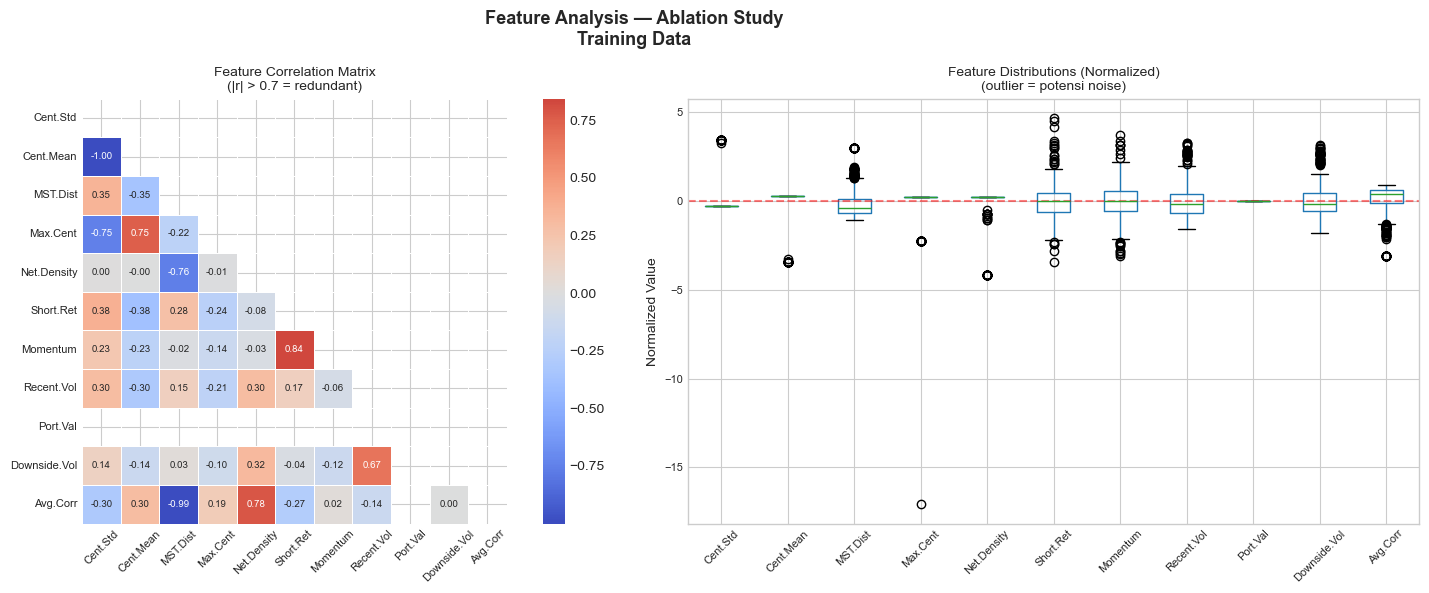


High-correlation pairs (|r| > 0.6):
  Cent.Std ↔ Cent.Mean: r = -1.000
  Cent.Std ↔ Max.Cent: r = -0.752
  Cent.Mean ↔ Max.Cent: r = 0.752
  MST.Dist ↔ Net.Density: r = -0.758
  MST.Dist ↔ Avg.Corr: r = -0.994
  Net.Density ↔ Avg.Corr: r = 0.783
  Short.Ret ↔ Momentum: r = 0.843
  Recent.Vol ↔ Downside.Vol: r = 0.665


In [6]:
# Kumpulkan semua fitur dari training data
all_features = []
baseline_cfg = ABLATION_CONFIGS['E5_AddBoth']  # config terlengkap

print('Collecting features for correlation analysis...')
for i in range(SET_WINDOW, len(ret_train)):
    win = ret_train.iloc[i - SET_WINDOW : i]
    nw, corr_f, _ = compute_network_features(win)
    mkt = compute_market_features(win)
    extra = compute_extra_features(win, corr_f, ['downside_vol', 'avg_corr'])
    all_features.append(np.concatenate([nw, mkt, extra]))

feat_names = [
    'Cent.Std', 'Cent.Mean', 'MST.Dist', 'Max.Cent', 'Net.Density',
    'Short.Ret', 'Momentum', 'Recent.Vol', 'Port.Val',
    'Downside.Vol', 'Avg.Corr'
]

df_feat = pd.DataFrame(all_features, columns=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis — Ablation Study\nTraining Data', fontsize=13, fontweight='bold')

# Heatmap korelasi
ax1 = axes[0]
corr_matrix = df_feat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 7})
ax1.set_title('Feature Correlation Matrix\n(|r| > 0.7 = redundant)', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

# Distribusi fitur (boxplot)
ax2 = axes[1]
df_normalized = (df_feat - df_feat.mean()) / (df_feat.std() + 1e-8)
df_normalized.boxplot(ax=ax2, rot=45, fontsize=8)
ax2.set_title('Feature Distributions (Normalized)\n(outlier = potensi noise)', fontsize=10)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('ablation_results/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print pasangan fitur yang berkorelasi tinggi
print('\nHigh-correlation pairs (|r| > 0.6):')
for i in range(len(feat_names)):
    for j in range(i+1, len(feat_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {feat_names[i]} ↔ {feat_names[j]}: r = {r:.3f}')

## Phase 5: Ablation Environment

In [7]:
def precompute_ablation_data(returns_data, config, window_size=30):
    """Precompute obs cache untuk satu ablation config."""
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    n_steps = len(returns_data) - window_size
    print(f'  Precomputing {n_steps} steps...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape

        # Build observation
        obs, corr_f, cent_vec = build_observation(win, config, port_val=0.0)
        obs_cache[i] = obs

        # Optimization cache
        sigma  = win.std().values
        mu     = win.mean().values
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        opt_cache[i] = (cov_f, cent_vec, mu)

        # Baseline return cache
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)

    print(f'  Done! obs_dim={len(obs_cache[window_size])}')
    return obs_cache, opt_cache, baseline_ret_cache


class AblationPortfolioEnv(gym.Env):
    """
    Environment untuk ablation study.
    Mendukung observation space dengan dimensi berbeda per config.
    Reward: Sortino Ratio (konsisten untuk semua eksperimen).
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache, config,
                 window_size=30, gamma_center=1.0,
                 sortino_window=20, mar=0.0):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache
        self.config             = config
        self.window_size        = window_size
        self.gamma_center       = gamma_center
        self.sortino_window     = sortino_window
        self.mar                = mar
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        self._ret_buffer        = []
        self._rew_mean          = 0.0
        self._rew_M2            = 0.0
        self._rew_count         = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        # Update port_val in market features jika tersedia
        if self.config['use_market']:
            offset = 5 if self.config['use_network'] else 0
            if offset + 3 < len(obs):
                obs[offset + 3] = self.port_val - 1
        return obs

    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def _compute_sortino_reward(self, buf):
        arr = np.array(buf)
        downside = arr[arr < self.mar]
        if len(downside) == 0:
            return arr.mean() * np.sqrt(252) * 10
        downside_std = np.sqrt(np.mean(downside**2))
        return arr.mean() / (downside_std + 1e-8) * 10

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        self._rew_mean    = 0.0
        self._rew_M2      = 0.0
        self._rew_count   = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > self.sortino_window:
            self._ret_buffer.pop(0)

        if len(self._ret_buffer) >= 5:
            raw = self._compute_sortino_reward(self._ret_buffer)
        else:
            raw = port_ret * 100

        reward = self._normalize_reward(raw)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, float(reward), done, False, {}


print('AblationPortfolioEnv defined.')

AblationPortfolioEnv defined.


## Phase 6: Backtest Engine & Strategy Classes

In [8]:
class AblationStrategy:
    """SAC strategy dengan ablation config tertentu."""
    def __init__(self, name, model_path, config, gamma_center=1.0):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.is_static    = config.get('static_gamma') is not None
        
        if self.is_static:
            self.model = None
            self.last_gamma = config['static_gamma']
        else:
            self.model        = SAC.load(model_path)
            self.last_gamma   = gamma_center

    def compute_weights(self, returns_window, port_val=1.0):
        if self.is_static:
            self.last_gamma = self.config['static_gamma']
            return get_centrality_weights(returns_window, gamma=self.last_gamma)

        obs, corr_f, cent_vec = build_observation(returns_window, self.config,
                                                   port_val=port_val - 1.0)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7):
    """Run backtest; tracks portfolio value so observation stays consistent with training."""
    rets, dates, gamma_history = [], [], []
    current_weights = None
    current_gamma   = 1.0
    port_val        = 1.0   # track cumulative portfolio value
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            # Pass live port_val so market feature F9 is realistic
            if hasattr(strategy, 'is_static') and strategy.is_static:
                current_weights = strategy.compute_weights(window_df)
            else:
                current_weights = strategy.compute_weights(window_df, port_val=port_val)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(current_gamma)
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


print('Backtest engine defined.')

Backtest engine defined.


## Phase 7: Training — Semua Ablation Configs

Melatih SAC untuk setiap kombinasi fitur × seed.

In [9]:
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,   # was 1000; reduced so SAC trains within TRAIN_STEPS
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}  # {(exp_id, seed): model_path}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{'='*60}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')
    print(f'  Network: {config["use_network"]} | Market: {config["use_market"]} | Extra: {config["extra_features"]}')
    print('Precomputing data...')

    obs_cache, opt_cache, baseline_ret_cache = precompute_ablation_data(
        ret_train, config, window_size=SET_WINDOW
    )

    for seed in SEEDS:
        model_name = f'ablation_{exp_id}_seed{seed}'
        
        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} requires no training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue
            
        print(f'  Training seed={seed}...')

        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, baseline_ret_cache, config,
            window_size=SET_WINDOW,
            gamma_center=GAMMA_CENTER,
            sortino_window=SORTINO_WINDOW
        )

        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    ✓ Saved: {model_name}.zip')

print('\n=== Semua model ablation selesai dilatih ===')


Experiment: E0_Baseline | obs_dim=9
  Network: True | Market: True | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=9
  Training seed=42...


Output()

Output()

    ✓ Saved: ablation_E0_Baseline_seed42.zip
  Training seed=123...


Output()

...

Output()

    ✓ Saved: ablation_E5_AddBoth_seed42.zip
  Training seed=123...


Output()

    ✓ Saved: ablation_E5_AddBoth_seed123.zip
  Training seed=77...


    ✓ Saved: ablation_E5_AddBoth_seed77.zip

Experiment: Comp_Static_Gamma0 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma0 requires no training.

Experiment: Comp_Static_Gamma1 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma1 requires no training.

Experiment: Comp_Static_Gamma2 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma2 requires no training.

=== Semua model ablation selesai dilatih ===


## Phase 8: Backtest — Training & Testing Data

In [10]:
# ================================================================
# Jalankan backtest untuk semua eksperimen & kedua periode
# ================================================================

ablation_results = {}  # {exp_id: {'train': {seed: ret}, 'test': {seed: ret}}}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]

        # Training backtest
        strat_tr = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_tr, _ = run_backtest(strat_tr, ret_train, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['train'][seed] = ret_tr

        # Testing backtest
        strat_te = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_te, _ = run_backtest(strat_te, ret_test, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['test'][seed] = ret_te

        print(f'  seed={seed} | Train Sortino: {calculate_sortino(ret_tr):.4f} | Test Sortino: {calculate_sortino(ret_te):.4f}')

print('\n✓ Semua backtest selesai.')


Backtest: E0_Baseline
  seed=42 | Train Sortino: -0.4612 | Test Sortino: -0.1513
  seed=123 | Train Sortino: -0.4578 | Test Sortino: -0.1513
  seed=77 | Train Sortino: -0.4619 | Test Sortino: -0.1513

Backtest: E1_NoNetwork
  seed=42 | Train Sortino: -0.3865 | Test Sortino: -0.1513
  seed=123 | Train Sortino: -0.4082 | Test Sortino: -0.2255
  seed=77 | Train Sortino: -0.3700 | Test Sortino: -0.1513

Backtest: E2_NoMarket
  seed=42 | Train Sortino: -0.4633 | Test Sortino: -0.1513
  seed=123 | Train Sortino: -0.3476 | Test Sortino: -0.1513
  seed=77 | Train Sortino: -0.3425 | Test Sortino: -0.1513

Backtest: E3_AddDownside
  seed=42 | Train Sortino: -0.4625 | Test Sortino: -0.1513
  seed=123 | Train Sortino: -0.3923 | Test Sortino: -0.1023
  seed=77 | Train Sortino: -0.3423 | Test Sortino: -0.1691

Backtest: E4_AddAvgCorr
  seed=42 | Train Sortino: -0.4589 | Test Sortino: -0.1513
  seed=123 | Train Sortino: -0.3522 | Test Sortino: -0.0787
  seed=77 | Train Sortino: -0.3428 | Test Sortin

## Phase 9: Hasil Ablation Study

In [11]:
# ================================================================
# Agregasi hasil: Mean ± Std Sortino per eksperimen
# ================================================================

summary_rows = []

for exp_id, config in ABLATION_CONFIGS.items():
    train_sortinos = [calculate_sortino(ablation_results[exp_id]['train'][s]) for s in SEEDS]
    test_sortinos  = [calculate_sortino(ablation_results[exp_id]['test'][s])  for s in SEEDS]

    # Agregasi mean return untuk metrik lain
    mean_train_ret = pd.concat([ablation_results[exp_id]['train'][s] for s in SEEDS], axis=1).mean(axis=1)
    mean_test_ret  = pd.concat([ablation_results[exp_id]['test'][s]  for s in SEEDS], axis=1).mean(axis=1)
    train_m = calculate_metrics(mean_train_ret)
    test_m  = calculate_metrics(mean_test_ret)

    obs_dim = get_obs_dim(config)
    feature_desc = []
    if config.get('static_gamma') is not None:
        feature_desc.append(f'Static Gamma {config["static_gamma"]}')
    else:
        if config['use_network']: feature_desc.append('Network(5)')
        if config['use_market']:  feature_desc.append('Market(4)')
        for e in config['extra_features']: feature_desc.append(e)

    summary_rows.append({
        'Experiment'        : exp_id,
        'Features'          : ' + '.join(feature_desc),
        'Obs Dim'           : obs_dim,
        # Training
        'Sortino Train (mean)': np.mean(train_sortinos),
        'Sortino Train (std)' : np.std(train_sortinos),
        'Sharpe Train'        : train_m['Sharpe Ratio'],
        'MaxDD Train'         : train_m['Max Drawdown'],
        # Testing
        'Sortino Test (mean)' : np.mean(test_sortinos),
        'Sortino Test (std)'  : np.std(test_sortinos),
        'Sharpe Test'         : test_m['Sharpe Ratio'],
        'MaxDD Test'          : test_m['Max Drawdown'],
        # Gap
        'Sortino Gap'         : np.mean(train_sortinos) - np.mean(test_sortinos),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('ablation_results/ablation_summary.csv')

print('='*70)
print('ABLATION STUDY RESULTS — SORTINO RATIO (Mean ± Std across seeds)')
print('='*70)
print(summary_df[[
    'Features', 'Obs Dim',
    'Sortino Train (mean)', 'Sortino Train (std)',
    'Sortino Test (mean)',  'Sortino Test (std)',
    'Sortino Gap'
]].round(4).to_string())
print('='*70)

# Ranking berdasarkan Sortino Test
ranked = summary_df.sort_values('Sortino Test (mean)', ascending=False)
print('\n🏆 RANKING (by Sortino Test):')
for rank, (exp_id, row) in enumerate(ranked.iterrows(), 1):
    print(f'  #{rank} {exp_id}: Sortino Test = {row["Sortino Test (mean)"]:.4f} ± {row["Sortino Test (std)"]:.4f}')

ABLATION STUDY RESULTS — SORTINO RATIO (Mean ± Std across seeds)
                                                            Features  Obs Dim  Sortino Train (mean)  Sortino Train (std)  Sortino Test (mean)  Sortino Test (std)  Sortino Gap
Experiment                                                                                                                                                                    
E0_Baseline                                   Network(5) + Market(4)        9               -0.4603               0.0018              -0.1513              0.0000      -0.3090
E1_NoNetwork                                               Market(4)        4               -0.3882               0.0157              -0.1760              0.0350      -0.2122
E2_NoMarket                                               Network(5)        5               -0.3845               0.0558              -0.1513              0.0000      -0.2332
E3_AddDownside                 Network(5) + Market(4) + down

## Phase 10: Visualisasi Ablation Study

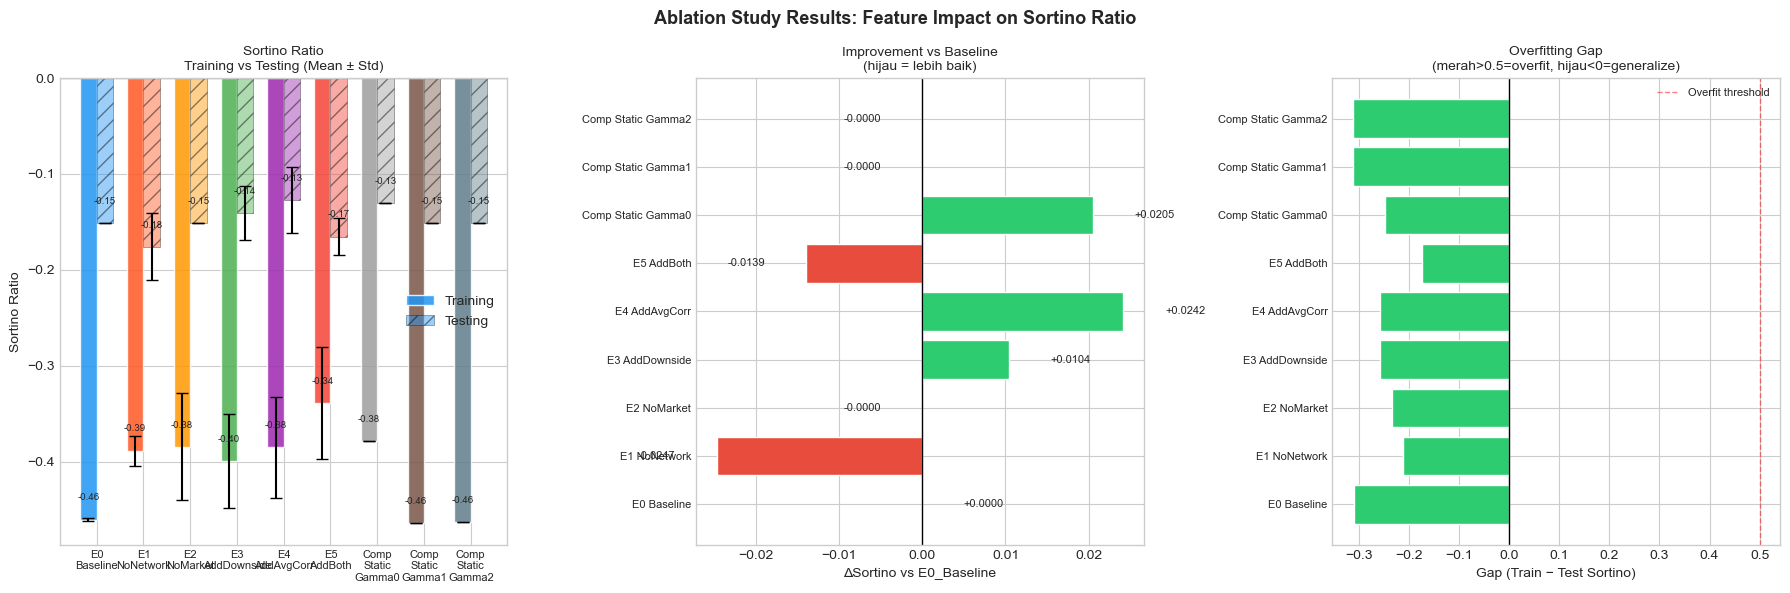

Saved: ablation_results/ablation_sortino_comparison.png


In [12]:
# ================================================================
# VISUALISASI 1: Grouped Bar Chart — Sortino Train vs Test
# ================================================================

exp_ids    = list(ABLATION_CONFIGS.keys())
train_means = summary_df.loc[exp_ids, 'Sortino Train (mean)'].values
train_stds  = summary_df.loc[exp_ids, 'Sortino Train (std)'].values
test_means  = summary_df.loc[exp_ids, 'Sortino Test (mean)'].values
test_stds   = summary_df.loc[exp_ids, 'Sortino Test (std)'].values

x     = np.arange(len(exp_ids))
width = 0.35

ABLATION_COLORS = {
    'E0_Baseline'    : '#2196F3',
    'E1_NoNetwork'   : '#FF5722',
    'E2_NoMarket'    : '#FF9800',
    'E3_AddDownside' : '#4CAF50',
    'E4_AddAvgCorr'  : '#9C27B0',
    'E5_AddBoth'     : '#F44336',
    'Comp_Static_Gamma0': '#9E9E9E',
    'Comp_Static_Gamma1': '#795548',
    'Comp_Static_Gamma2': '#607D8B',
}
colors = [ABLATION_COLORS[e] for e in exp_ids]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ablation Study Results: Feature Impact on Sortino Ratio',
             fontsize=13, fontweight='bold')

# --- Panel 1: Grouped Bar ---
ax = axes[0]
bars1 = ax.bar(x - width/2, train_means, width, yerr=train_stds,
               label='Training', color=colors, alpha=0.85, capsize=4, edgecolor='white')
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds,
               label='Testing', color=colors, alpha=0.45, capsize=4,
               edgecolor='black', linewidth=0.5, hatch='//')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([e.replace('_', '\n') for e in exp_ids], fontsize=8)
ax.set_ylabel('Sortino Ratio')
ax.set_title('Sortino Ratio\nTraining vs Testing (Mean ± Std)', fontsize=10)
ax.legend()
for b, v in zip(bars1, train_means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'{v:.2f}', ha='center', fontsize=7)
for b, v in zip(bars2, test_means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'{v:.2f}', ha='center', fontsize=7)

# --- Panel 2: Delta vs Baseline (E0) ---
ax2 = axes[1]
baseline_test = summary_df.loc['E0_Baseline', 'Sortino Test (mean)']
deltas = test_means - baseline_test
delta_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
bars3 = ax2.barh([e.replace('_', ' ') for e in exp_ids], deltas,
                 color=delta_colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('ΔSortino vs E0_Baseline')
ax2.set_title('Improvement vs Baseline\n(hijau = lebih baik)', fontsize=10)
ax2.tick_params(axis='y', labelsize=8)
for bar, d in zip(bars3, deltas):
    ax2.text(d + (0.005 if d >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{d:+.4f}', va='center',
             ha='left' if d >= 0 else 'right', fontsize=8)

# --- Panel 3: Overfitting Gap ---
ax3 = axes[2]
gaps = summary_df.loc[exp_ids, 'Sortino Gap'].values
gap_colors = ['#e74c3c' if g > 0.5 else '#2ecc71' if g < 0 else '#f39c12' for g in gaps]
bars4 = ax3.barh([e.replace('_', ' ') for e in exp_ids], gaps,
                 color=gap_colors, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Overfit threshold')
ax3.set_xlabel('Gap (Train − Test Sortino)')
ax3.set_title('Overfitting Gap\n(merah>0.5=overfit, hijau<0=generalize)', fontsize=10)
ax3.tick_params(axis='y', labelsize=8)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results/ablation_sortino_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results/ablation_sortino_comparison.png')

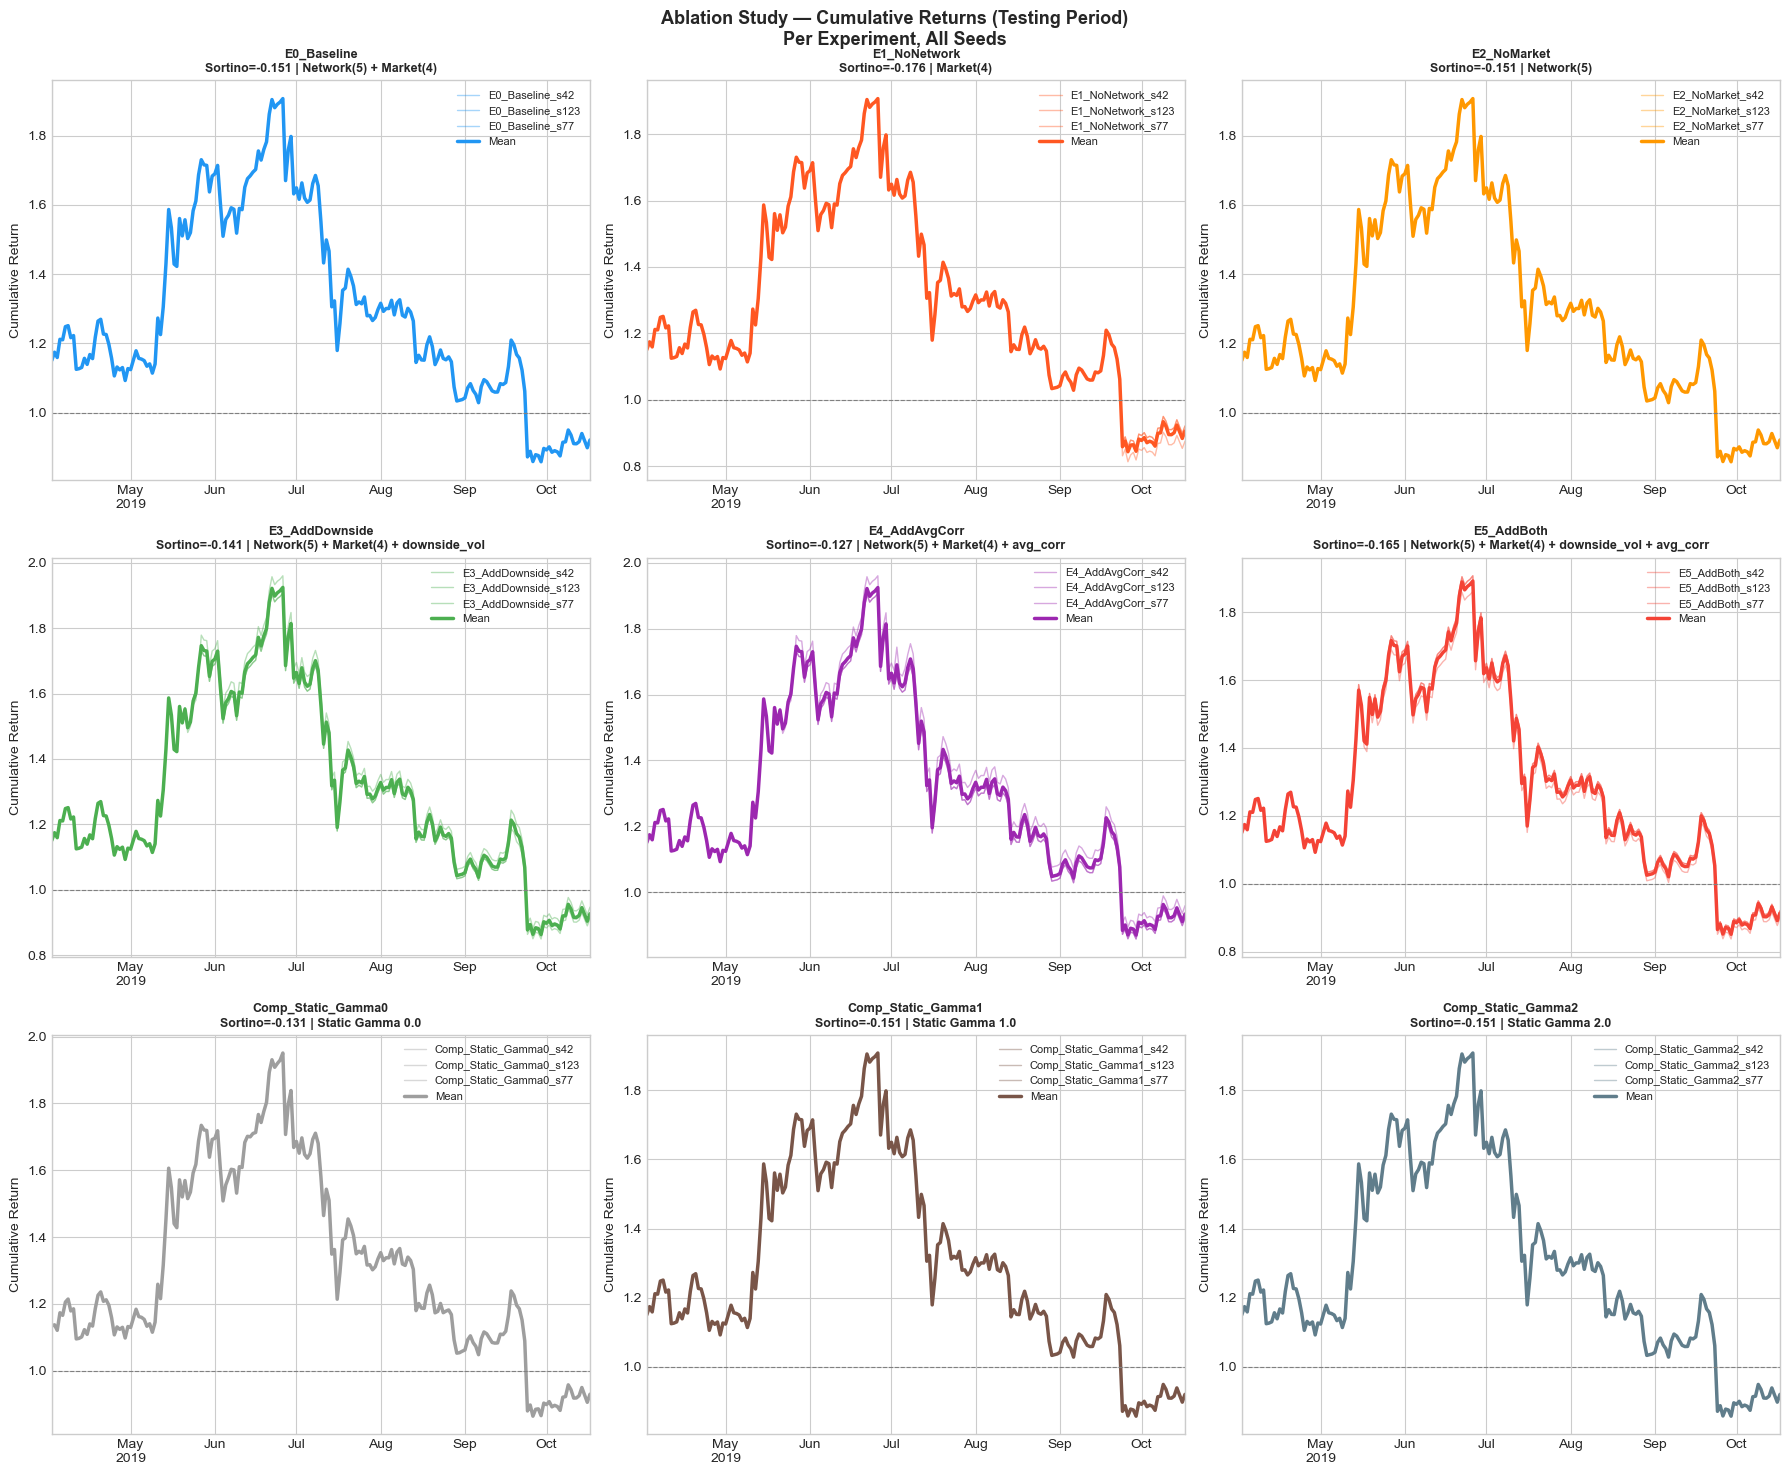

Saved: ablation_results/ablation_cumret_testing.png


In [13]:
# ================================================================
# VISUALISASI 2: Cumulative Returns semua eksperimen (Testing)
# ================================================================

n_exp = len(ABLATION_CONFIGS)
n_cols = 3
n_rows = (n_exp + n_cols - 1) // n_cols  # ceil division → handles any number of experiments
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Ablation Study — Cumulative Returns (Testing Period)\nPer Experiment, All Seeds',
             fontsize=13, fontweight='bold')
# Hide spare subplots (when n_exp not divisible by n_cols)
for spare_ax in axes.flatten()[n_exp:]:
    spare_ax.set_visible(False)

for ax, (exp_id, config) in zip(axes.flatten(), ABLATION_CONFIGS.items()):
    color = ABLATION_COLORS[exp_id]
    seed_rets = []
    for seed in SEEDS:
        ret = ablation_results[exp_id]['test'][seed]
        cum = (1 + ret).cumprod()
        cum.plot(ax=ax, alpha=0.4, color=color, linewidth=1)
        seed_rets.append(cum)

    # Mean across seeds
    mean_cum = pd.concat(seed_rets, axis=1).mean(axis=1)
    mean_cum.plot(ax=ax, color=color, linewidth=2.5, label='Mean')

    sortino_test = summary_df.loc[exp_id, 'Sortino Test (mean)']
    feat_desc = summary_df.loc[exp_id, 'Features']
    ax.set_title(f'{exp_id}\nSortino={sortino_test:.3f} | {feat_desc}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results/ablation_cumret_testing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results/ablation_cumret_testing.png')

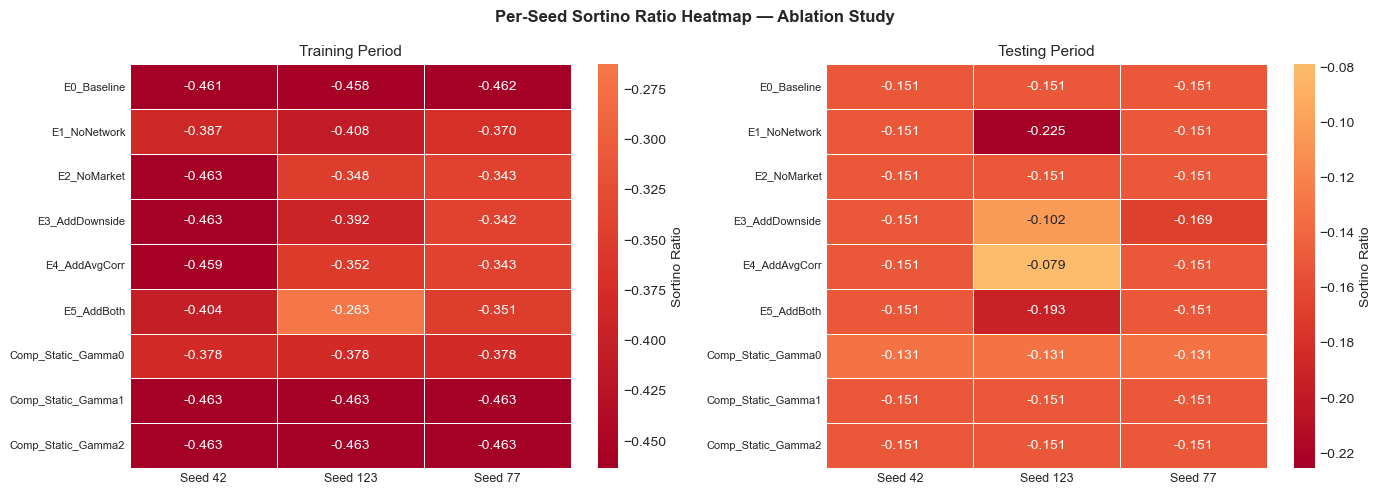

Saved: ablation_results/ablation_heatmap_perseed.png


In [14]:
# ================================================================
# VISUALISASI 3: Per-Seed Sortino Heatmap
# ================================================================

# Buat matriks: baris = eksperimen, kolom = seed
heatmap_train = pd.DataFrame(index=exp_ids, columns=[f'Seed {s}' for s in SEEDS], dtype=float)
heatmap_test  = pd.DataFrame(index=exp_ids, columns=[f'Seed {s}' for s in SEEDS], dtype=float)

for exp_id in exp_ids:
    for seed in SEEDS:
        heatmap_train.loc[exp_id, f'Seed {seed}'] = calculate_sortino(
            ablation_results[exp_id]['train'][seed])
        heatmap_test.loc[exp_id, f'Seed {seed}'] = calculate_sortino(
            ablation_results[exp_id]['test'][seed])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Seed Sortino Ratio Heatmap — Ablation Study',
             fontsize=12, fontweight='bold')

for ax, hm, title in zip(axes,
                          [heatmap_train, heatmap_test],
                          ['Training Period', 'Testing Period']):
    hm_clipped = hm.clip(-10, 10)  # clip outlier (inf Sortino)
    sns.heatmap(hm_clipped.astype(float), ax=ax, annot=True, fmt='.3f',
                cmap='RdYlGn', center=0, linewidths=0.5,
                cbar_kws={'label': 'Sortino Ratio'})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig('ablation_results/ablation_heatmap_perseed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results/ablation_heatmap_perseed.png')

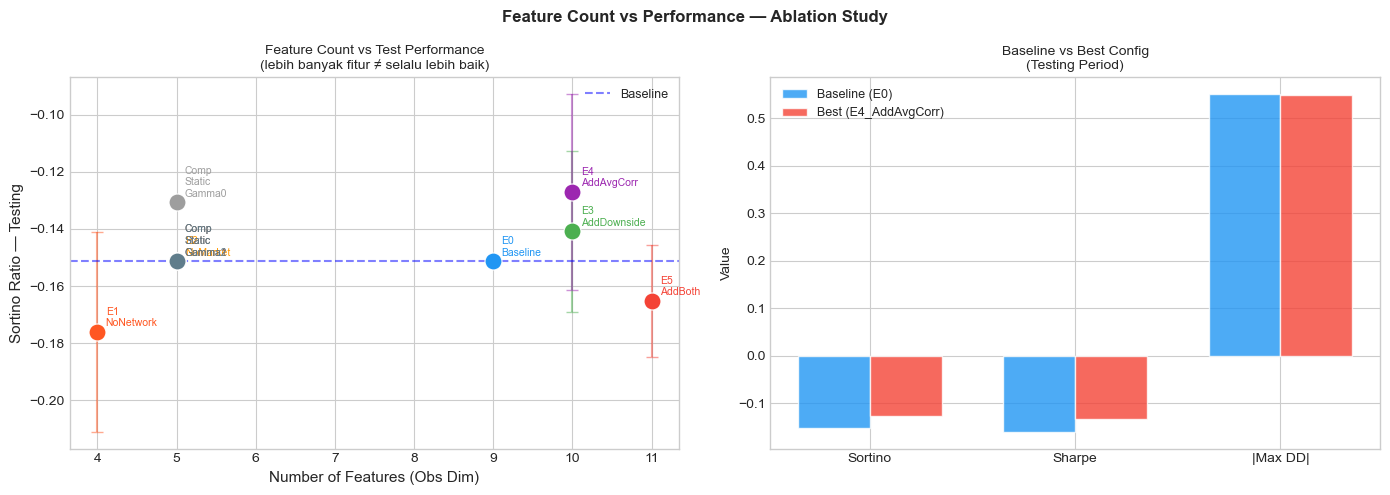

Saved: ablation_results/ablation_feature_count_vs_perf.png


In [15]:
# ================================================================
# VISUALISASI 4: Scatter — Obs Dim vs Sortino Test
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Count vs Performance — Ablation Study', fontsize=12, fontweight='bold')

obs_dims     = summary_df['Obs Dim'].values
sortino_tests = summary_df['Sortino Test (mean)'].values
sortino_stds  = summary_df['Sortino Test (std)'].values

# Scatter: obs dim vs Sortino test
ax1 = axes[0]
for i, exp_id in enumerate(exp_ids):
    ax1.scatter(obs_dims[i], sortino_tests[i], s=150,
                color=ABLATION_COLORS[exp_id], zorder=5, edgecolor='white', linewidth=0.8)
    ax1.annotate(exp_id.replace('_', '\n'), (obs_dims[i], sortino_tests[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=7.5,
                 color=ABLATION_COLORS[exp_id])
    ax1.errorbar(obs_dims[i], sortino_tests[i], yerr=sortino_stds[i],
                 fmt='none', color=ABLATION_COLORS[exp_id], capsize=4, alpha=0.5)

ax1.set_xlabel('Number of Features (Obs Dim)', fontsize=11)
ax1.set_ylabel('Sortino Ratio — Testing', fontsize=11)
ax1.set_title('Feature Count vs Test Performance\n(lebih banyak fitur ≠ selalu lebih baik)', fontsize=10)
ax1.axhline(summary_df.loc['E0_Baseline', 'Sortino Test (mean)'],
            color='blue', linestyle='--', alpha=0.5, label='Baseline')
ax1.legend(fontsize=9)

# Bar: Semua metrik untuk E0 vs best
ax2 = axes[1]
best_exp = summary_df.sort_values('Sortino Test (mean)', ascending=False).index[0]
metrics_compare = ['Sortino Ratio', 'Sharpe Ratio', 'Max Drawdown']

for exp_id, label, color in [
    ('E0_Baseline', 'Baseline (E0)', '#2196F3'),
    (best_exp, f'Best ({best_exp})', '#F44336')
]:
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    m = calculate_metrics(mean_ret)
    vals = [m['Sortino Ratio'], m['Sharpe Ratio'], abs(m['Max Drawdown'])]
    ax2.bar(np.arange(3) + (0 if exp_id == 'E0_Baseline' else 0.35),
            vals, 0.35, label=label, color=color, alpha=0.8, edgecolor='white')

ax2.set_xticks(np.arange(3) + 0.175)
ax2.set_xticklabels(['Sortino', 'Sharpe', '|Max DD|'])
ax2.set_title(f'Baseline vs Best Config\n(Testing Period)', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_ylabel('Value')

plt.tight_layout()
plt.savefig('ablation_results/ablation_feature_count_vs_perf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results/ablation_feature_count_vs_perf.png')

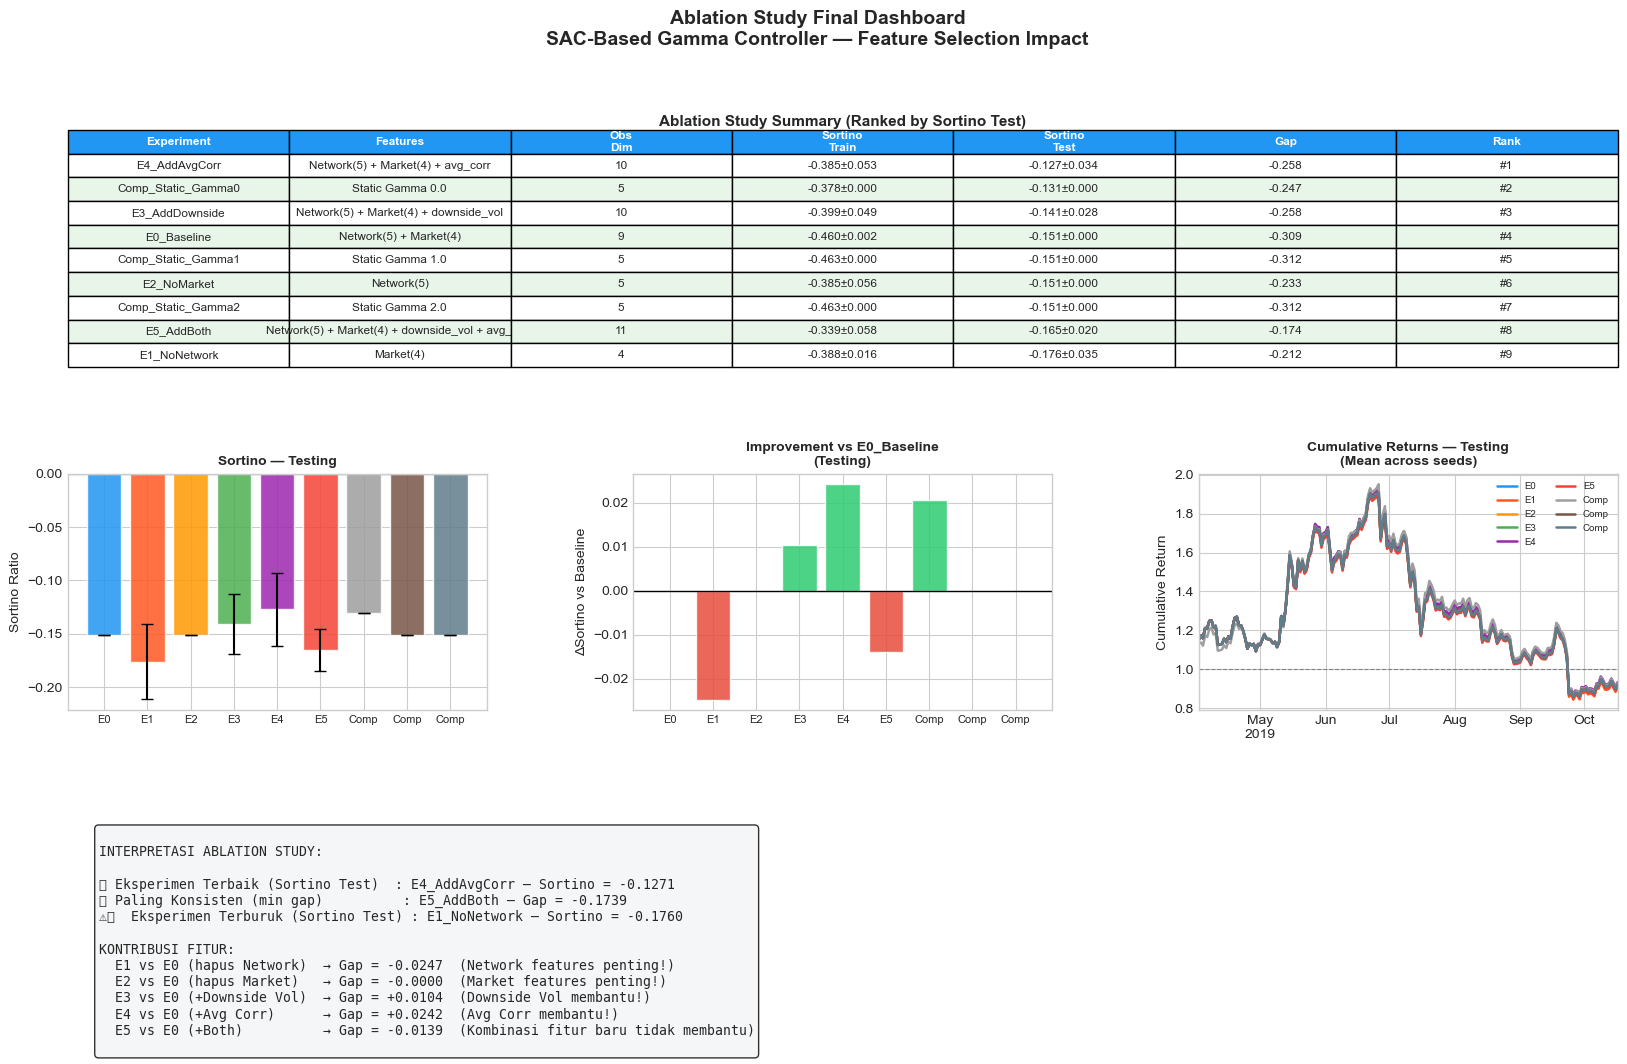


✅ Ablation Study Complete!
Outputs saved to ablation_results/:
  - ablation_summary.csv
  - feature_correlation.png
  - ablation_sortino_comparison.png
  - ablation_cumret_testing.png
  - ablation_heatmap_perseed.png
  - ablation_feature_count_vs_perf.png
  - ablation_final_dashboard.png


In [16]:
# ================================================================
# VISUALISASI 5: Final Dashboard
# ================================================================

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Ablation Study Final Dashboard\nSAC-Based Gamma Controller — Feature Selection Impact',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Summary table (text)
ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis('off')
tbl_data = []
col_labels = ['Experiment', 'Features', 'Obs\nDim',
              'Sortino\nTrain', 'Sortino\nTest', 'Gap', 'Rank']
ranked_df = summary_df.sort_values('Sortino Test (mean)', ascending=False)
for rank, (exp_id, row) in enumerate(ranked_df.iterrows(), 1):
    tbl_data.append([
        exp_id,
        row['Features'],
        int(row['Obs Dim']),
        f"{row['Sortino Train (mean)']:.3f}±{row['Sortino Train (std)']:.3f}",
        f"{row['Sortino Test (mean)']:.3f}±{row['Sortino Test (std)']:.3f}",
        f"{row['Sortino Gap']:+.3f}",
        f'#{rank}'
    ])

tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2196F3')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, (exp_id, _) in enumerate(ranked_df.iterrows(), 1):
    fc = '#E8F5E9' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(fc)
ax_tbl.set_title('Ablation Study Summary (Ranked by Sortino Test)',
                 fontsize=11, fontweight='bold', pad=3)

# Panel 2: Sortino Bar (Testing)
ax2 = fig.add_subplot(gs[1, 0])
exp_list   = list(summary_df.index)
test_vals  = summary_df['Sortino Test (mean)'].values
test_err   = summary_df['Sortino Test (std)'].values
bcolors    = [ABLATION_COLORS[e] for e in exp_list]
bars = ax2.bar(range(len(exp_list)), test_vals, yerr=test_err,
               color=bcolors, edgecolor='white', capsize=4, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(len(exp_list)))
ax2.set_xticklabels([e.split('_')[0] for e in exp_list], fontsize=8)
ax2.set_ylabel('Sortino Ratio')
ax2.set_title('Sortino — Testing', fontsize=10, fontweight='bold')

# Panel 3: Delta vs baseline
ax3 = fig.add_subplot(gs[1, 1])
baseline_val = summary_df.loc['E0_Baseline', 'Sortino Test (mean)']
deltas2 = test_vals - baseline_val
dc2 = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas2]
ax3.bar(range(len(exp_list)), deltas2, color=dc2, edgecolor='white', alpha=0.85)
ax3.axhline(0, color='black', linewidth=1)
ax3.set_xticks(range(len(exp_list)))
ax3.set_xticklabels([e.split('_')[0] for e in exp_list], fontsize=8)
ax3.set_ylabel('ΔSortino vs Baseline')
ax3.set_title('Improvement vs E0_Baseline\n(Testing)', fontsize=10, fontweight='bold')

# Panel 4: Cumret Testing (mean per exp)
ax4 = fig.add_subplot(gs[1, 2])
for exp_id in exp_ids:
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    (1 + mean_ret).cumprod().plot(
        ax=ax4, label=exp_id.split('_')[0],
        color=ABLATION_COLORS[exp_id], linewidth=1.8
    )
ax4.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax4.set_title('Cumulative Returns — Testing\n(Mean across seeds)', fontsize=10, fontweight='bold')
ax4.legend(fontsize=7, ncol=2)
ax4.set_ylabel('Cumulative Return')

# Panel 5: Interpretasi
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
best_test_exp  = ranked_df.index[0]
worst_test_exp = ranked_df.index[-1]
best_gap_exp   = summary_df['Sortino Gap'].abs().idxmin()

interpretasi = f"""
INTERPRETASI ABLATION STUDY:

🥇 Eksperimen Terbaik (Sortino Test)  : {best_test_exp} — Sortino = {summary_df.loc[best_test_exp, 'Sortino Test (mean)']:.4f}
📊 Paling Konsisten (min gap)          : {best_gap_exp} — Gap = {summary_df.loc[best_gap_exp, 'Sortino Gap']:+.4f}
⚠️  Eksperimen Terburuk (Sortino Test) : {worst_test_exp} — Sortino = {summary_df.loc[worst_test_exp, 'Sortino Test (mean)']:.4f}

KONTRIBUSI FITUR:
  E1 vs E0 (hapus Network)  → Gap = {summary_df.loc['E1_NoNetwork','Sortino Test (mean)'] - baseline_val:+.4f}  {'(Network features penting!)' if summary_df.loc['E1_NoNetwork','Sortino Test (mean)'] < baseline_val else '(Network features tidak krusial)'}
  E2 vs E0 (hapus Market)   → Gap = {summary_df.loc['E2_NoMarket','Sortino Test (mean)'] - baseline_val:+.4f}  {'(Market features penting!)' if summary_df.loc['E2_NoMarket','Sortino Test (mean)'] < baseline_val else '(Market features tidak krusial)'}
  E3 vs E0 (+Downside Vol)  → Gap = {summary_df.loc['E3_AddDownside','Sortino Test (mean)'] - baseline_val:+.4f}  {'(Downside Vol membantu!)' if summary_df.loc['E3_AddDownside','Sortino Test (mean)'] > baseline_val else '(Downside Vol tidak membantu)'}
  E4 vs E0 (+Avg Corr)      → Gap = {summary_df.loc['E4_AddAvgCorr','Sortino Test (mean)'] - baseline_val:+.4f}  {'(Avg Corr membantu!)' if summary_df.loc['E4_AddAvgCorr','Sortino Test (mean)'] > baseline_val else '(Avg Corr tidak membantu)'}
  E5 vs E0 (+Both)          → Gap = {summary_df.loc['E5_AddBoth','Sortino Test (mean)'] - baseline_val:+.4f}  {'(Kedua fitur baru membantu!)' if summary_df.loc['E5_AddBoth','Sortino Test (mean)'] > baseline_val else '(Kombinasi fitur baru tidak membantu)'}
"""
ax5.text(0.02, 0.95, interpretasi, transform=ax5.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.8))

plt.savefig('ablation_results/ablation_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Ablation Study Complete!')
print('Outputs saved to ablation_results/:')
print('  - ablation_summary.csv')
print('  - feature_correlation.png')
print('  - ablation_sortino_comparison.png')
print('  - ablation_cumret_testing.png')
print('  - ablation_heatmap_perseed.png')
print('  - ablation_feature_count_vs_perf.png')
print('  - ablation_final_dashboard.png')